In [1]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.text_factory = lambda x: x.decode('utf-8', 'ignore')

In [2]:
# Load all individuals with occupations and an impact date
query = """
    SELECT 
        i.wikidata_id,
        i.occupations_en,
        CAST(SUBSTR(
            CASE 
                WHEN id.impact_date LIKE '-%' THEN SUBSTR(id.impact_date, 1, 5)
                ELSE SUBSTR(id.impact_date, 1, 4)
            END, 1, 5) AS INTEGER) as impact_year
    FROM individuals i
    JOIN individuals_impact_date id ON i.wikidata_id = id.wikidata_id
    WHERE i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df = pl.read_database(query, conn)
print(f"Total individuals with occupations and impact dates: {len(df):,}")

Total individuals with occupations and impact dates: 5,556,247


In [3]:
# Split occupations (semicolon-separated) and explode into separate rows
df_exploded = (
    df
    .with_columns(
        pl.col('occupations_en').str.split('; ').alias('occupation_list')
    )
    .explode('occupation_list')
    .rename({'occupation_list': 'occupation'})
    .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
)

print(f"Total occupation entries: {len(df_exploded):,}")

Total occupation entries: 8,752,590


In [4]:
# Split by period: before 1900 and 1900+
df_before_1900 = df_exploded.filter(pl.col('impact_year') < 1900)
df_after_1900 = df_exploded.filter(pl.col('impact_year') >= 1900)

print(f"Occupation entries before 1900: {len(df_before_1900):,}")
print(f"Occupation entries 1900+: {len(df_after_1900):,}")

Occupation entries before 1900: 1,467,458
Occupation entries 1900+: 7,285,132


In [5]:
# Top 20 occupations + "Others" for the rest (top 20 covers the bulk of entries)
def get_top_occupations_with_others(df_period, n_top=20):
    """Get top N occupations and group the rest as Others."""
    occ_counts = (
        df_period
        .group_by('occupation')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
    )
    total = occ_counts['count'].sum()

    top = occ_counts.head(n_top)
    top_total = top['count'].sum()
    others_count = total - top_total

    labels = top['occupation'].to_list() + ['Others']
    sizes = top['count'].to_list() + [others_count]

    top_pct = top_total / total * 100
    return labels, sizes, total, top_pct

labels_before, sizes_before, total_before, pct_before = get_top_occupations_with_others(df_before_1900)
labels_after, sizes_after, total_after, pct_after = get_top_occupations_with_others(df_after_1900)

print(f"Before 1900: top 20 cover {pct_before:.1f}% of {total_before:,} entries")
print(f"After 1900: top 20 cover {pct_after:.1f}% of {total_after:,} entries")

Before 1900: top 20 cover 47.2% of 1,467,458 entries
After 1900: top 20 cover 41.0% of 7,285,132 entries


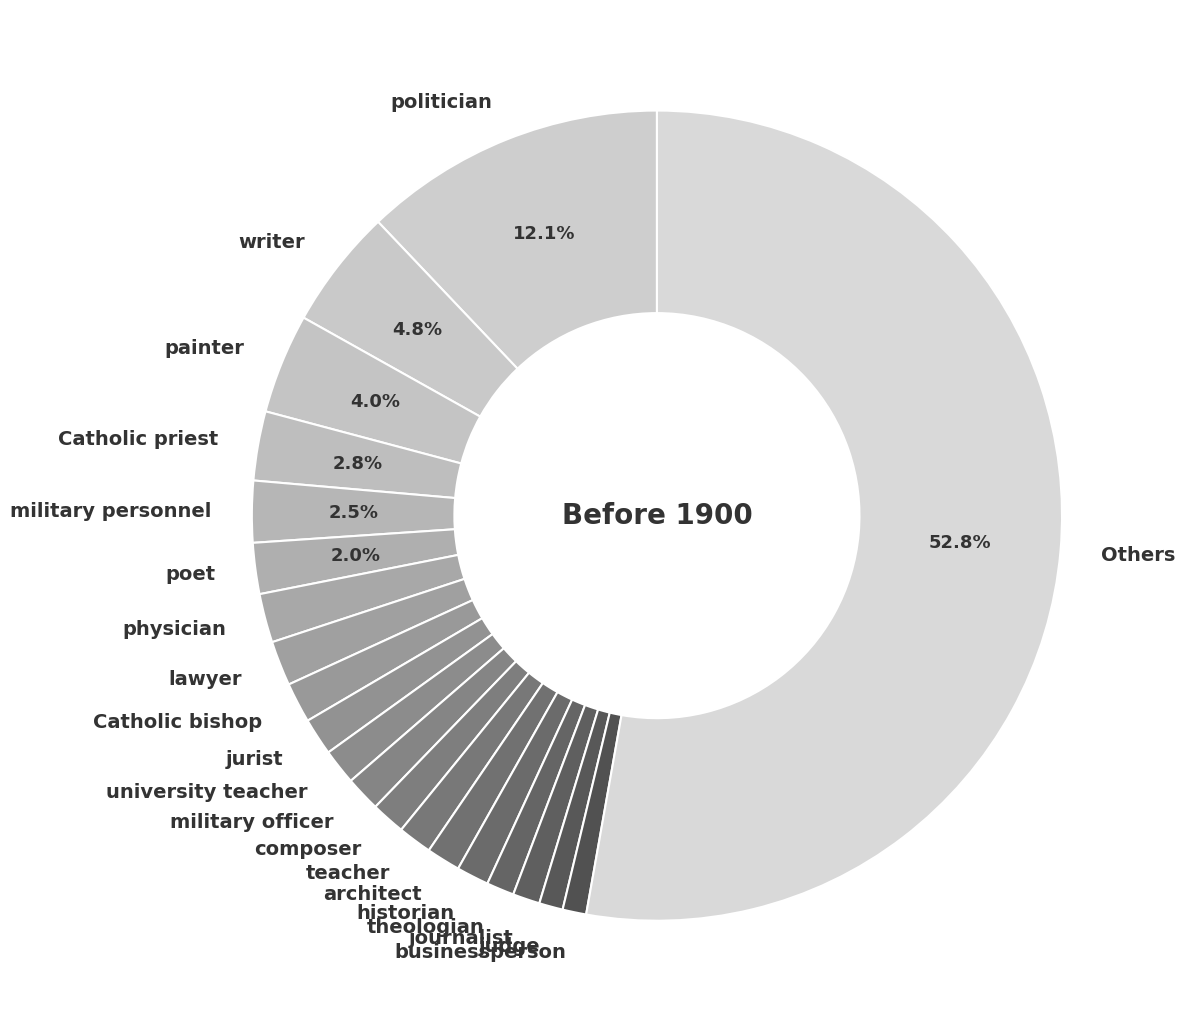

In [6]:
# Donut chart — Before 1900
n = len(labels_before)
colors_before = list(plt.cm.Greys(np.linspace(0.3, 0.75, n - 1))) + ['#d9d9d9']

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts, autotexts = ax.pie(
    sizes_before,
    labels=labels_before,
    colors=colors_before,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(14)
    text.set_color('#333')
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('#333')
    autotext.set_fontweight('bold')

ax.text(0, 0, 'Before 1900',
        ha='center', va='center', fontsize=20, color='#333', fontweight='bold')

plt.tight_layout()
plt.show()

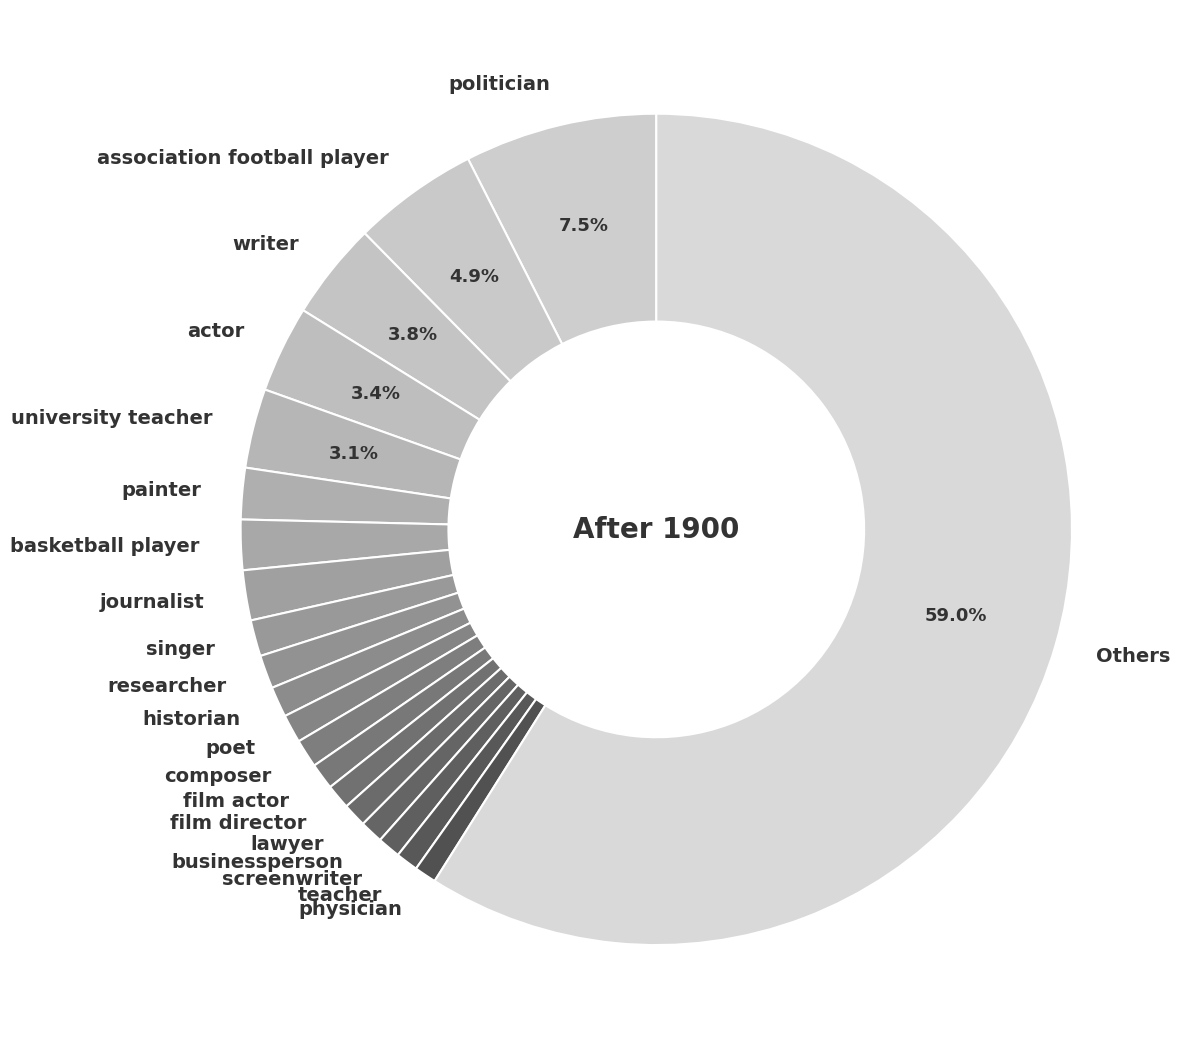

In [7]:
# Donut chart — After 1900
n = len(labels_after)
colors_after = list(plt.cm.Greys(np.linspace(0.3, 0.75, n - 1))) + ['#d9d9d9']

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts, autotexts = ax.pie(
    sizes_after,
    labels=labels_after,
    colors=colors_after,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(14)
    text.set_color('#333')
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('#333')
    autotext.set_fontweight('bold')

ax.text(0, 0, 'After 1900',
        ha='center', va='center', fontsize=20, color='#333', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Load individuals for specific polities with their occupations
polity_query = """
    SELECT 
        ic.wikidata_id,
        i.occupations_en,
        ic.impact_date as impact_year,
        ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE ic.polity_name IN ('Roman Empire;(Roman Empire)', 'Tang Dynasty;(Tang Dynasty)')
      AND i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df_polities = pl.read_database(polity_query, conn)

# Split into two polities
df_roman = df_polities.filter(pl.col('polity_name') == 'Roman Empire;(Roman Empire)')
df_tang = df_polities.filter(pl.col('polity_name') == 'Tang Dynasty;(Tang Dynasty)')

print(f"Roman Empire individuals with occupations: {len(df_roman):,}")
print(f"Tang Dynasty individuals with occupations: {len(df_tang):,}")

Roman Empire individuals with occupations: 3,289
Tang Dynasty individuals with occupations: 4,426


In [9]:
# Explode occupations for each polity
def explode_occupations(df_pol):
    return (
        df_pol
        .with_columns(
            pl.col('occupations_en').str.split('; ').alias('occupation_list')
        )
        .explode('occupation_list')
        .rename({'occupation_list': 'occupation'})
        .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
    )

df_roman_exp = explode_occupations(df_roman)
df_tang_exp = explode_occupations(df_tang)

labels_roman, sizes_roman, total_roman, pct_roman = get_top_occupations_with_others(df_roman_exp)
labels_tang, sizes_tang, total_tang, pct_tang = get_top_occupations_with_others(df_tang_exp, n_top=10)

print(f"Roman Empire: top 20 cover {pct_roman:.1f}% of {total_roman:,} occupation entries")
print(f"Tang Dynasty: top 20 cover {pct_tang:.1f}% of {total_tang:,} occupation entries")

Roman Empire: top 20 cover 79.3% of 4,766 occupation entries
Tang Dynasty: top 20 cover 93.2% of 5,200 occupation entries


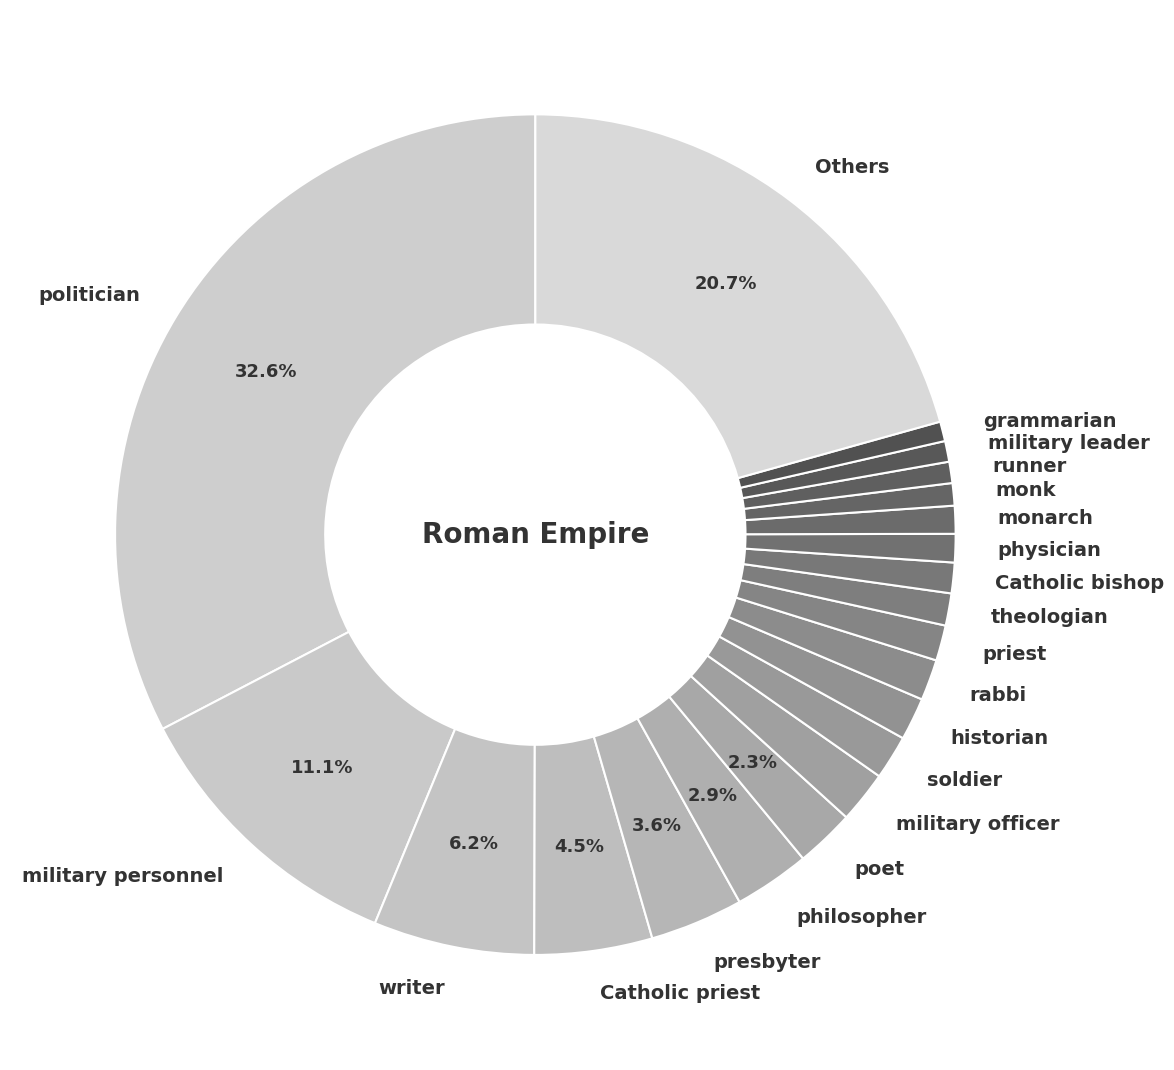

In [10]:
# Donut chart — Roman Empire
n = len(labels_roman)
colors_roman = list(plt.cm.Greys(np.linspace(0.3, 0.75, n - 1))) + ['#d9d9d9']

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts, autotexts = ax.pie(
    sizes_roman,
    labels=labels_roman,
    colors=colors_roman,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(14)
    text.set_color('#333')
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('#333')
    autotext.set_fontweight('bold')

ax.text(0, 0, 'Roman Empire',
        ha='center', va='center', fontsize=20, color='#333', fontweight='bold')

plt.tight_layout()
plt.show()

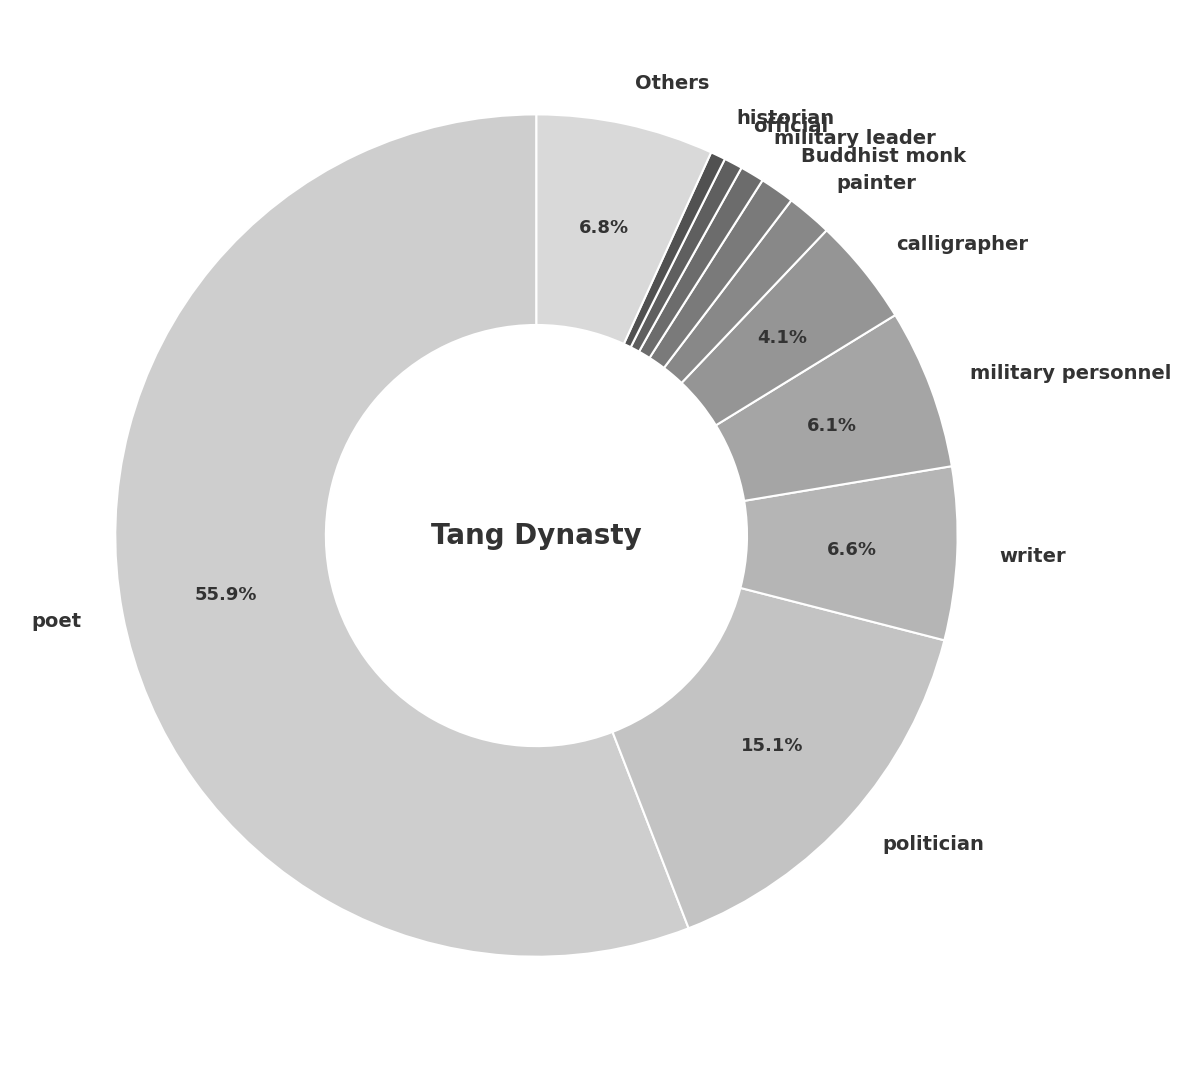

In [11]:
# Donut chart — Tang Dynasty
n = len(labels_tang)
colors_tang = list(plt.cm.Greys(np.linspace(0.3, 0.75, n - 1))) + ['#d9d9d9']

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts, autotexts = ax.pie(
    sizes_tang,
    labels=labels_tang,
    colors=colors_tang,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(14)
    text.set_color('#333')
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('#333')
    autotext.set_fontweight('bold')

ax.text(0, 0, 'Tang Dynasty',
        ha='center', va='center', fontsize=20, color='#333', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
conn.close()